# โค้ด 7.1 หาขอบภาพ MRI ด้วย Canny

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/aiforeveryone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 accident.mp4		  emails_spam.csv   rice.png	      traffic.mp4
'AI update 5 Dec.pages'   mri_scan.jpg	    rice_result.jpg   traffic.png
 ball.jpg		  number8n.png	    sketch	      woman.mp4
 cnn			  number8.png	    source.jpg	      ืีnumber8n.png
 coins_result.png	  rice.jpg	    target
 coint.png		  rice_mask.jpg     test.png


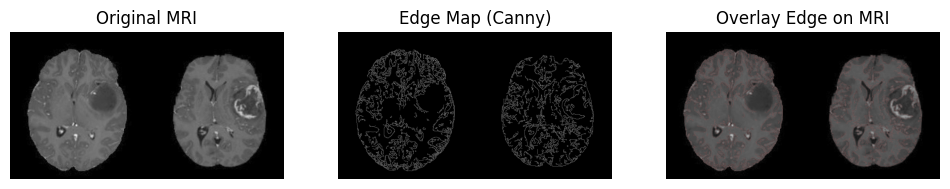

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# โหลดภาพ MRI จริง
img = cv2.imread("/content/drive/MyDrive/aiforeveryone/mri_scan.jpg", cv2.IMREAD_GRAYSCALE)  # MRI มักเป็น grayscale

# ตรวจสอบว่าโหลดภาพสำเร็จหรือไม่
if img is None:
    print("Error: Could not load image 'mri_scan.jpg'. Please ensure the file exists and the path is correct.")
else:
    # ถ้ามี brightness/contrast ที่ไม่ดี -> ปรับ
    img_equalized = cv2.equalizeHist(img)

    # ใช้ Gaussian blur ลด noise
    blur = cv2.GaussianBlur(img_equalized, (5,5), 0)

    # ตรวจขอบโดย Canny
    edges = cv2.Canny(blur, threshold1=50, threshold2=150)

    # ใช้เส้นขอบซ้อนทับบนภาพจริง เปลี่ยน edges เป็นสีแดงบนภาพ RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    red_edges = np.zeros_like(img_rgb)
    red_edges[..., 0] = edges  # B
    red_edges[..., 1] = 0      # G
    red_edges[..., 2] = 0      # R
    overlay = cv2.addWeighted(img_rgb, 0.8, red_edges, 0.2, 0)

    # แสดงผล
    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.title("Original MRI")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Edge Map (Canny)")
    plt.imshow(edges, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay Edge on MRI")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

# โค้ด 7.2 นับเหรียญจากภาพ

In [ ]:
import cv2
import numpy as np
from pathlib import Path

def hu_log(hu: np.ndarray) -> np.ndarray:
    """
    Hu moments มีค่าน้อยมาก/มากมาก จึงนิยมแปลงเป็น log scale:
    hu_log_i = -sign(hu_i) * log10(|hu_i|)
    """
    hu = hu.flatten()
    eps = 1e-30
    return -np.sign(hu) * np.log10(np.abs(hu) + eps)

def coin_like_by_hu(hu_l: np.ndarray) -> bool:
    """
    เงื่อนไขแบบง่าย (heuristic) เพื่อกรองวัตถุแปลก ๆ
    - สำหรับวัตถุกลมสมมาตร (เช่น เหรียญ) ค่าบางตัวมัก “ไม่แปรปรวนมาก”
    - เกณฑ์นี้ไม่ใช่มาตรฐานตายตัว ต้องปรับตามภาพจริง
    """
    # ตัวอย่างเกณฑ์ที่มักใช้: hu[0] ไม่สุดโต่ง, และ hu[1] ไม่ใหญ่เกินไป
    # (คุณสามารถพิมพ์ค่า hu_l ดูแล้วปรับ threshold ให้เข้ากับภาพของคุณ)
    return (-2.5 <= hu_l[0] <= 3.5) and (hu_l[1] <= 6.0)

def count_coins(image_path: str, out_path: str = "/content/drive/MyDrive/aiforeveryone/coins_result.png", debug: bool = True) -> int:
    image_path = str(image_path)
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"อ่านไฟล์ภาพไม่ได้: {image_path}")

    # 1) Preprocess
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (7, 7), 0)

    # 2) Threshold (Otsu) — ได้ mask ของเหรียญ (ขาว) / พื้นหลัง (ดำ)
    # บางภาพต้อง invert ให้เหรียญเป็นสีขาวเสมอ
    _, th = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # ถ้าเหรียญเป็นดำ พื้นหลังเป็นขาว ให้กลับสี
    # (เช็คง่าย ๆ จากจำนวนพิกเซลขาว: ถ้าขาวเยอะเกินไปแปลว่า background เป็นขาว)
    if cv2.countNonZero(th) > (th.size * 0.6):
        th = cv2.bitwise_not(th)

    # 3) Morphology ทำให้ขอบเนียน ลดรู
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 4) Find contours
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 5) Filter + Hu moments
    h, w = gray.shape
    min_area = int(0.0005 * (h * w))  # ปรับได้ตามขนาดภาพ
    max_area = int(0.2 * (h * w))     # กันวัตถุใหญ่มาก (เช่น ทั้งภาพ)

    coins = []
    vis = img.copy()

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue

        peri = cv2.arcLength(cnt, True)
        if peri <= 0:
            continue

        # circularity = 4πA / P^2  (ใกล้ 1 เมื่อกลมมาก)
        circularity = (4.0 * np.pi * area) / (peri * peri)

        # เงื่อนไขกลมแบบง่าย (ปรับตามภาพจริง)
        if circularity < 0.65:
            continue

        # Hu moments
        m = cv2.moments(cnt)
        hu = cv2.HuMoments(m)
        hu_l = hu_log(hu)

        if not coin_like_by_hu(hu_l):
            continue

        # ผ่านทุกเงื่อนไข => ถือว่าเป็นเหรียญ
        coins.append(cnt)

        # วาดกรอบและเขียนข้อมูล
        x, y, ww, hh = cv2.boundingRect(cnt)
        cv2.rectangle(vis, (x, y), (x + ww, y + hh), (0, 255, 0), 2)
        cv2.putText(vis, f"Circ={circularity:.2f}", (x, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

        if debug:
            # แสดง Hu ตัวแรก ๆ (พอให้ดูแนวโน้ม)
            hu_txt = f"Hu0={hu_l[0]:.2f},Hu1={hu_l[1]:.2f}"
            cv2.putText(vis, hu_txt, (x, y + hh + 16),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1, cv2.LINE_AA)

    # สรุปผล
    cv2.putText(vis, f"Coins: {len(coins)}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 255), 3, cv2.LINE_AA)

    cv2.imwrite(out_path, vis)

    # ถ้ารันในเครื่องตัวเอง เปิดดูได้
    # cv2.imshow("threshold", th); cv2.imshow("result", vis); cv2.waitKey(0)

    return len(coins)

if __name__ == "__main__":
    # เปลี่ยนชื่อไฟล์เป็นรูปเหรียญของคุณ
    img_path = "/content/drive/MyDrive/aiforeveryone/coint.png"
    n = count_coins(img_path, out_path="/content/drive/MyDrive/aiforeveryone/coins_result.png", debug=True)
    print("Coin count =", n)


Coin count = 9


#โค้ด 7.3 สกัดฟีเจอร์ด้วย Aspect Ratio กรณีศึกษาหาค่าเฉลี่ยความยาวเมล็ดข้าวพันธุ์หนึ่ง

หาขนาดภาพ เพื่อจะแปลงพิกเซลเป็นเซนติเมตร
ถ้าผลลัพธ์เป็น 72 จะใช้ไม่ได้ต้องหาขนาดอ้างอิง เช่น วัดขนาดข้าว 1 เม็ด พร้อมถ่ายภาพไม้บรรทัด จะทราบหน่วย pixel:centimeters แล้วค่อยใช้คำนวณหาขนาดข้าวข้าวที่อ่านได้ซึ่งเป็นค่าเฉลี่ย
อนึ่ง อัลกอริทึมนี้อาจไม่แม่นยำมากเท่าไหร่ ผู้อ่านอาจจะมองเห็นความท้าทายในการนับที่มีหลาย ๆ เม็ด

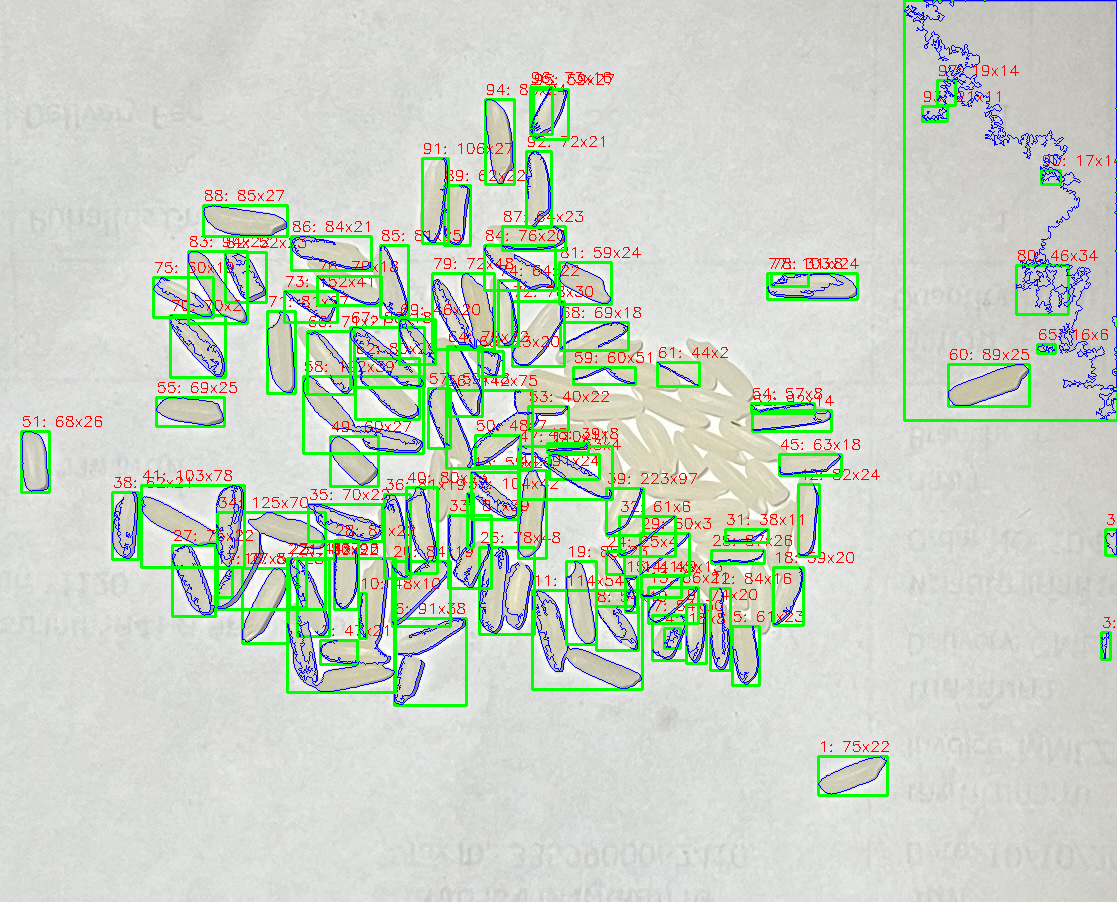

    id  area_px  perimeter_px   length_px    width_px  aspect_ratio
0    1   1297.0    175.338093   75.253769   22.870777      3.290390
1    2     70.0    156.367531   47.165611   21.597597      2.183836
2    3     69.5     73.698484   26.483084    6.723475      3.938898
3    4     54.5    101.154328   18.471989    8.746237      2.111993
4    5    173.0    253.480229   61.255566   23.729078      2.581456
..  ..      ...           ...         ...         ...           ...
93  94   1611.5    197.639610   85.936142   24.740303      3.473528
94  95    136.5    138.953318   59.578938   27.737160      2.147983
95  96     57.0    158.166521   73.190826   16.001217      4.574079
96  97     70.5    120.610171   19.840364   14.919123      1.329861
97  98  32973.5   3768.318214  407.785858  196.694916      2.073190

[98 rows x 6 columns]


In [ ]:
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow # Import cv2_imshow

# ----------------------------
# 1) โหลดภาพ
# ----------------------------
img = cv2.imread("/content/drive/MyDrive/aiforeveryone/rice.jpg")  # พื้นหลังสีขาว
display = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ----------------------------
# 2) Threshold
# ----------------------------
_, thresh = cv2.threshold(
    gray, 200, 255, cv2.THRESH_BINARY_INV
)

# ----------------------------
# 3) หา Contours
# ----------------------------
contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

features = []
idx = 1

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 50:  # กรอง noise
        continue

    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)

    # Fit ellipse เพื่อหาความยาว-กว้าง
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        length_px = max(ellipse[1])
        width_px = min(ellipse[1])
    else:
        length_px = max(w, h)
        width_px = min(w, h)

    aspect_ratio = length_px / width_px

    features.append({
        "id": idx,
        "area_px": area,
        "perimeter_px": perimeter,
        "length_px": length_px,
        "width_px": width_px,
        "aspect_ratio": aspect_ratio
    })

    # ----------------------------
    # 4) วาดผลลัพธ์บนภาพ
    # ----------------------------
    cv2.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.drawContours(display, [cnt], -1, (255, 0, 0), 1)

    label = f"{idx}: {int(length_px)}x{int(width_px)}"
    cv2.putText(
        display,
        label,
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1
    )

    idx += 1

# ----------------------------
# 5) แสดงภาพ
# ----------------------------
cv2_imshow(display) # Changed cv2.imshow to cv2_imshow
cv2.waitKey(0)
cv2.destroyAllWindows()

# ----------------------------
# 6) แสดงตารางฟีเจอร์
# ----------------------------
df = pd.DataFrame(features)
print(df)


##หาขนาดเฉลี่ยของเมล็ดข้าว แปลงให้เป็นหน่วยเซนติเมตร  

In [ ]:
#เอาเฉพาะความยาวที่ < 100 px มีพิจารณา แล้วหาค่าเฉลี่ย
df = df[df["length_px"] < 100]
avg_length = df["length_px"].mean()
print(avg_length)
#คำนวณหาขนาดเป็นเซนติเมตร
#สูตรคำนวณหาด้วย DPI ของภาพ ซึ่งจากโค้ดข้างล่างได้ 300
cm = (avg_length / 300) * 2.54
print("Centimeter :", cm)

62.44063274159151
1.5859920716364242
Centimeter : 0.5286640238788081


#หาว่าภาพมีความละเอียดอย่างไร
ในกรณีที่ไม่สามารถหาค่าได้ เช่น เป็น 72 ควรใช้วิธีการวัดขนาดอ้างอิง

In [ ]:
from PIL import Image

img = Image.open("/content/drive/MyDrive/aiforeveryone/rice.jpg")
dpi = img.info.get("dpi")

print("DPI:", dpi)


DPI: (300, 300)


#โค้ด 7.4 หาข้อมูลคุณลักษณะเชิงรูปร่างด้วย Convex Hull

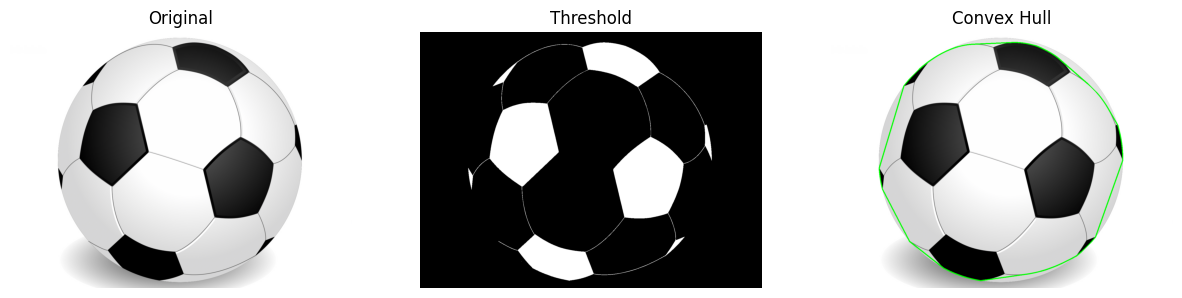

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) โหลดภาพ
img = cv2.imread("/content/drive/MyDrive/aiforeveryone/ball.jpg")

# ตรวจสอบว่าโหลดภาพสำเร็จหรือไม่
if img is None:
    print("Error: Could not load image 'ball.jpg'. Please ensure the file exists and the path is correct.")
else:
    orig = img.copy()

    # 2) แปลงเป็น grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3) ทำ threshold หรือ Canny edge แล้วแต่ความเหมาะสม
    # ถ้ารูปมีสีชัดเจนใช้ threshold ได้
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # หรือใช้ขอบแบบ Canny (ทางเลือก)
    # thresh = cv2.Canny(gray, 100, 200)

    # 4) หา contour ของวัตถุ
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # ถ้าเจอหลาย contour เลือกอันที่ใหญ่สุด
    cnt = max(contours, key=cv2.contourArea)

    # 5) คำนวณ Convex Hull
    hull = cv2.convexHull(cnt)

    # 6) วาด hull ลงบนภาพ
    cv2.drawContours(orig, [hull], -1, (0, 255, 0), 3)  # สีเขียว

    # 7) แสดงผล (ต้องใช้ plt.imshow ใน Colab แทน cv2.imshow)
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Threshold")
    plt.imshow(thresh, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Convex Hull")
    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()


# โค้ด 7.5 ภาพ MRI หาขอบ และ Convex hull, Aspect ratio

=== MRI Shape Analysis After Canny ===
Area: 136.0
Perimeter: 76.28427076339722
Aspect Ratio (W/H): 1.909
Extent: 0.589
Solidity (Convexity): 0.743
Concavity (Hull - Area): 47.000


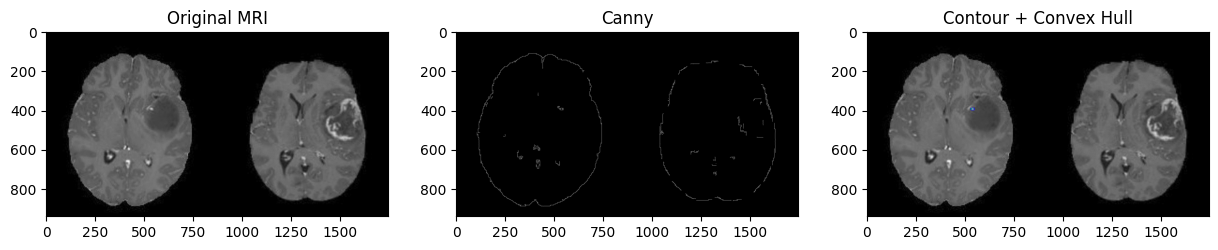

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1) Load MRI image
# ------------------------------
img = cv2.imread('/content/drive/MyDrive/aiforeveryone/mri_scan.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ------------------------------
# 2) Apply Canny
# ------------------------------
edges = cv2.Canny(gray, 80, 180)

# ------------------------------
# 3) Find contours
# ------------------------------
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# เลือก contour ที่ใหญ่ที่สุด (วัตถุหลักใน MRI)
cnt = max(contours, key=cv2.contourArea)

# ------------------------------
# 4) Shape Features
# ------------------------------
# พื้นที่
area = cv2.contourArea(cnt)

# ความยาวเส้นรอบรูป
perimeter = cv2.arcLength(cnt, True)

# กรอบสี่เหลี่ยมแนวนอน
x, y, w, h = cv2.boundingRect(cnt)
aspect_ratio = w / h

# Extent = area / area_of_bounding_box
extent = float(area) / (w * h)

# Convex Hull
hull = cv2.convexHull(cnt)
hull_area = cv2.contourArea(hull)
solidity = float(area) / hull_area

# ความเว้า = พื้นที่ Hull – พื้นที่จริง
concavity = hull_area - area

# ------------------------------
# 5) Draw results
# ------------------------------
result = img.copy()
cv2.drawContours(result, [cnt], -1, (0, 255, 0), 2)
cv2.drawContours(result, [hull], -1, (255, 0, 0), 2)

# ------------------------------
# 6) Print metrics
# ------------------------------
print("=== MRI Shape Analysis After Canny ===")
print(f"Area: {area}")
print(f"Perimeter: {perimeter}")
print(f"Aspect Ratio (W/H): {aspect_ratio:.3f}")
print(f"Extent: {extent:.3f}")
print(f"Solidity (Convexity): {solidity:.3f}")
print(f"Concavity (Hull - Area): {concavity:.3f}")

# ------------------------------
# 7) Plot
# ------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original MRI")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Canny")
plt.imshow(edges, cmap='gray')

plt.subplot(1,3,3)
plt.title("Contour + Convex Hull")
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

plt.show()


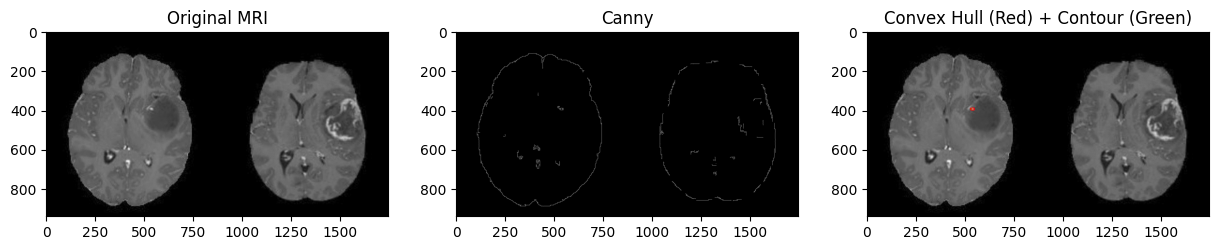

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1) Load MRI image
# ------------------------------
img = cv2.imread('/content/drive/MyDrive/aiforeveryone/mri_scan.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ------------------------------
# 2) Apply Canny Edge Detection
# ------------------------------
edges = cv2.Canny(gray, 80, 180)

# ------------------------------
# 3) Find contours
# ------------------------------
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)  # เอาเฉพาะวัตถุใหญ่สุด

# ------------------------------
# 4) Convex Hull
# ------------------------------
hull = cv2.convexHull(cnt)

# ------------------------------
# 5) Draw contour + hull
# ------------------------------
result = img.copy()

# วาด contour สีเขียว
cv2.drawContours(result, [cnt], -1, (0, 255, 0), 2)

# วาด hull สีแดง
cv2.drawContours(result, [hull], -1, (0, 0, 255), 3)  # RED

# ------------------------------
# 6) Show result
# ------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original MRI")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Canny")
plt.imshow(edges, cmap='gray')

plt.subplot(1,3,3)
plt.title("Convex Hull (Red) + Contour (Green)")
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

plt.show()


#โค้ด 7.6 หาข้อมูลคุณลักษณะ Color Histogram

ภาพที่ทดสอบจาด manowdee.com

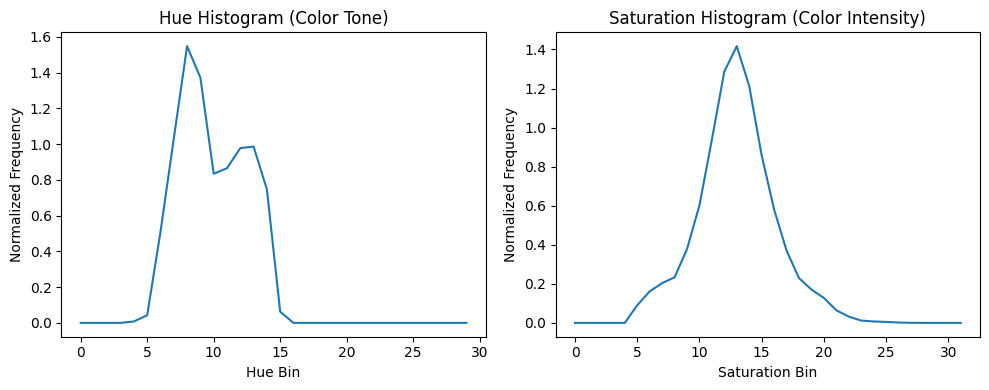

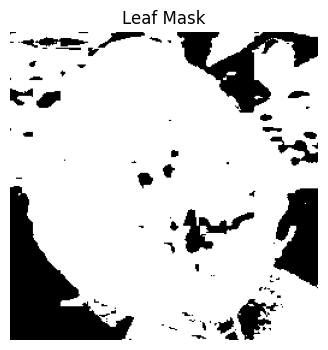

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_leaf_color_histogram(image_path, bins=(30, 32)):
    # อ่านภาพ
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("ไม่พบไฟล์ภาพ")

    image = cv2.resize(image, (256, 256))

    # แปลงเป็น HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # ช่วงสีเขียว (mask ใบไม้)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # คำนวณ Histogram (Hue + Saturation)
    hist = cv2.calcHist(
        [hsv],
        channels=[0, 1],
        mask=mask,
        histSize=bins,
        ranges=[0, 180, 0, 256]
    )

    cv2.normalize(hist, hist)
    return hist, mask


def plot_color_histogram(hist, bins=(30, 32)):
    plt.figure(figsize=(10, 4))

    # แยก Histogram ของ Hue และ Saturation
    hue_hist = hist.sum(axis=1)
    sat_hist = hist.sum(axis=0)

    # Plot Hue
    plt.subplot(1, 2, 1)
    plt.plot(hue_hist)
    plt.title("Hue Histogram (Color Tone)")
    plt.xlabel("Hue Bin")
    plt.ylabel("Normalized Frequency")

    # Plot Saturation
    plt.subplot(1, 2, 2)
    plt.plot(sat_hist)
    plt.title("Saturation Histogram (Color Intensity)")
    plt.xlabel("Saturation Bin")
    plt.ylabel("Normalized Frequency")

    plt.tight_layout()
    plt.show()


# =========================
# ตัวอย่างการใช้งาน
# =========================
if __name__ == "__main__":
    image_path = "/content/drive/MyDrive/aiforeveryone/leaf.png"   # เปลี่ยนเป็นภาพใบไม้ของคุณ

    hist, mask = extract_leaf_color_histogram(image_path)
    plot_color_histogram(hist)

    # แสดง mask (ดูว่าเลือกใบไม้ถูกไหม)
    plt.figure(figsize=(4, 4))
    plt.imshow(mask, cmap="gray")
    plt.title("Leaf Mask")
    plt.axis("off")
    plt.show()



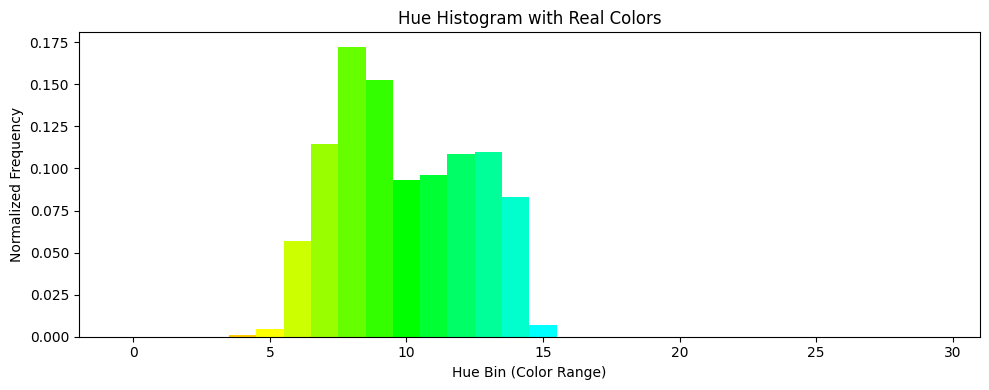

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_hue_histogram_with_colors(image_path, hue_bins=30):
    # อ่านภาพ
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("ไม่พบไฟล์ภาพ")

    image = cv2.resize(image, (256, 256))
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # mask สีเขียว (ใบไม้)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # คำนวณ Hue histogram อย่างเดียว
    hist = cv2.calcHist(
        [hsv],
        channels=[0],           # Hue only
        mask=mask,
        histSize=[hue_bins],
        ranges=[0, 180]
    )

    hist = hist.flatten()
    hist = hist / hist.sum()   # normalize

    # ===== สร้างสีของแต่ละ bin =====
    colors = []
    for i in range(hue_bins):
        hue_value = int((i / hue_bins) * 180)
        hsv_color = np.uint8([[[hue_value, 255, 255]]])
        bgr_color = cv2.cvtColor(hsv_color, cv2.COLOR_HSV2BGR)
        rgb_color = bgr_color[0][0][::-1] / 255.0
        colors.append(rgb_color)

    # ===== Plot =====
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(hue_bins), hist, color=colors, width=1.0)

    ax.set_title("Hue Histogram with Real Colors")
    ax.set_xlabel("Hue Bin (Color Range)")
    ax.set_ylabel("Normalized Frequency")

    plt.tight_layout()
    plt.show()


# =========================
# ตัวอย่างการใช้งาน
# =========================
if __name__ == "__main__":
    plot_hue_histogram_with_colors("/content/drive/MyDrive/aiforeveryone/leaf.png")


# โค้ด 7.7 การหาระดับการขาดน้ำจากใบพืช

In [4]:
import cv2
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# ======================================
# 1) สกัด Feature เชิงสถิติจากภาพ
# ======================================
def extract_statistical_color_features(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None

    image = cv2.resize(image, (256, 256))
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv)

    # mask สีเขียว (ใบไม้)
    green_mask = cv2.inRange(
        hsv,
        np.array([35, 40, 40]),
        np.array([85, 255, 255])
    )

    total_pixels = green_mask.size
    green_pixels = cv2.countNonZero(green_mask)

    # === Feature 1: สัดส่วนสีเขียว ===
    green_ratio = green_pixels / total_pixels

    if green_pixels == 0:
        return None

    # === Feature 2–5: สถิติของ Hue / Saturation ===
    mean_hue = np.mean(h[green_mask > 0])
    std_hue = np.std(h[green_mask > 0])

    mean_sat = np.mean(s[green_mask > 0])
    std_sat = np.std(s[green_mask > 0])

    return [
        green_ratio,
        mean_hue,
        std_hue,
        mean_sat,
        std_sat
    ]


# ======================================
# 2) โหลด Dataset
# ======================================
def load_dataset(dataset_path):
    X, y = [], []

    label_map = {
        "normal": 0,     # ปกติ
        "low": 1,  # ขาดน้ำ
        "high": 2     # ขาดน้ำมาก
    }

    for class_name, label in label_map.items():
        folder = os.path.join(dataset_path, class_name)
        if not os.path.exists(folder):
            print(f"Warning: Folder '{folder}' not found. Skipping class '{class_name}'.")
            continue
        for file in os.listdir(folder):
            img_path = os.path.join(folder, file)
            features = extract_statistical_color_features(img_path)
            if features is not None:
                X.append(features)
                y.append(label)

    return np.array(X), np.array(y)


# ======================================
# 3) Train Random Forest
# ======================================
dataset_path = "/content/drive/MyDrive/aiforeveryone/feature/dataset"
X, y = load_dataset(dataset_path)

# Ensure there is enough data for both training and testing
if len(X) < 2 or len(np.unique(y)) < 2:
    print("Error: Not enough data or classes to perform train_test_split and classification report.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y # Added stratify to ensure all classes are in test set if possible
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Get unique labels actually present in y_test
    actual_labels = np.unique(y_test)
    # Filter target names based on actual_labels
    all_target_names = {
        0: "ปกติ",
        1: "ขาดน้ำ",
        2: "ขาดน้ำมาก"
    }
    filtered_target_names = [all_target_names[label] for label in actual_labels]

    print(classification_report(
        y_test,
        y_pred,
        labels=actual_labels, # Explicitly pass the labels present in y_test
        target_names=filtered_target_names
    ))


    # ======================================
    # 4) ทำนายภาพใหม่
    # ======================================
    def predict_water_stress(image_path):
        features = extract_statistical_color_features(image_path)
        if features is None:
            return "Cannot extract features from image."
        pred = model.predict([features])[0]

        labels = {
            0: "ปกติ",
            1: "ขาดน้ำ",
            2: "ขาดน้ำมาก"
        }

        return labels[pred]


    # ======================================
    # 5) ตัวอย่างใช้งาน
    # ======================================
    result = predict_water_stress("/content/drive/MyDrive/aiforeveryone/leaf.png") # Changed from leaf.jpg to leaf.png
    print("ผลการประเมิน:", result)


              precision    recall  f1-score   support

        ปกติ       1.00      1.00      1.00         1
      ขาดน้ำ       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

ผลการประเมิน: ปกติ
